# DecoupleR

Test DecoupleR annotation

In [1]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import anndata as ad

# 1. Load Single Cell Data
adata = ad.io.read_h5ad('../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design.h5ad')

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Limit adata for tests to 5.000
adata = adata[:5000]

print(adata)

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


View of AnnData object with n_obs × n_vars = 5000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [4]:
import json

with open('../scumi-dev/R/marker_gene/human_pbmc_marker.json', 'r', encoding='utf-8') as file:
            marker_dict = json.load(file)

marker_df = pd.DataFrame.from_dict(marker_dict)

print(marker_df.head())

ValueError: All arrays must be of the same length

In [6]:
dc.op.show_resources()

,name,license
0,Adhesome,commercial
1,Almen2009,commercial
2,Baccin2019,academic
3,CORUM_Funcat,academic
4,CORUM_GO,academic
...,...,...
76,iTALK,academic
77,kinase.com,non_profit
78,scConnect,commercial
79,scConnect_complex,commercial


In [18]:
# Load marker genes
marker_df = dc.op.resource("CellMarker", organism="human") #PanglaoDB

# Format marker genes
marker_df = marker_df.rename(columns={"cell_type": "source", "genesymbol": "target"})
marker_df = marker_df[["source", "target"]]
marker_df = marker_df.drop_duplicates(subset=['source', 'target'])

print(marker_df.head())

AssertionError: name must be one of these: {'Kirouac2010', 'CORUM_GO', 'Adhesome', 'TopDB', 'GPCRdb', 'CPAD', 'Zhong2015', 'Guide2Pharma', 'scConnect', 'OPM', 'CancerDrugsDB', 'ICELLNET_complex', 'IntOGen', 'MSigDB', 'Matrisome', 'HumanCellMap', 'NetPath', 'DisGeNet', 'UniProt_topology', 'CellCall', 'HPA_subcellular', 'SignaLink_function', 'MatrixDB', 'Exocarta', 'LOCATE', 'CancerGeneCensus', 'CellChatDB_complex', 'ComPPI', 'ICELLNET', 'HPA_secretome', 'PanglaoDB', 'HGNC', 'InterPro', 'Ramilowski_location', 'CellPhoneDB', 'MCAM', 'HPA_tissue', 'KEGG-PC', 'CellTypist', 'HPMR', 'GO_Intercell', 'Phosphatome', 'CellCellInteractions', 'kinase.com', 'Phobius', 'Baccin2019', 'CSPA', 'Integrins', 'Almen2009', 'Ramilowski2015', 'UniProt_keyword', 'CellTalkDB', 'CancerSEA', 'CytoSig', 'Wang', 'Membranome', 'KEGG', 'CORUM_Funcat', 'Vesiclepedia', 'CellPhoneDB_complex', 'SIGNOR', 'Cellinker_complex', 'LRdb', 'SignaLink_pathway', 'connectomeDB2020', 'PROGENy', 'scConnect_complex', 'TCDB', 'CellChat

In [9]:
import scipy.sparse as sp

# 1. Sicherstellen, dass adata.X im korrekten CSR-Format vorliegt
if not isinstance(adata.X, sp.csr_matrix):
    print("Konvertiere Matrix zu CSR...")
    adata.X = sp.csr_matrix(adata.X)

# 2. Sicherstellen, dass keine NaN-Werte in der Referenzdatenbank sind
# (PanglaoDB hat manchmal leere Zeilen bei den Genen)
marker_df_clean = marker_df.dropna(subset=['source', 'target'])

# 3. Wichtig: Filtere PanglaoDB, sodass NUR Gene übrig bleiben, die AUCH in deinen Daten sind.
# Das verhindert, dass der Algorithmus mit leeren Vektoren abstürzt.
genes_in_data = set(adata.var_names)
marker_df_clean = marker_df_clean[marker_df_clean['target'].isin(genes_in_data)]

print(f"Schnittmenge der Gene: {len(marker_df_clean['target'].unique())} Gene stimmen überein.")

Schnittmenge der Gene: 427 Gene stimmen überein.


In [10]:
# Checken, was in deinen Single-Cell Daten steht
print("Deine Gen-Namen (Auszug):", adata.var_names[:5].tolist())

# Checken, was in PanglaoDB steht
print("PanglaoDB Gen-Namen (Auszug):", marker_df['target'].head().tolist())

Deine Gen-Namen (Auszug): ['MIR1302-2HG', 'AL627309.1', 'AL627309.3', 'AL627309.4', 'AL669831.2']
PanglaoDB Gen-Namen (Auszug): ['ACKR1', 'ACY3', 'ADCYAP1', 'ADGRG3', 'ADGRL4']


In [11]:
# 1. Gen-Namen bereinigen (Alles nach dem Punkt entfernen und in Großbuchstaben umwandeln)
# Aus 'AL627309.1' wird 'AL627309'
clean_names = [gene.split('.')[0].upper() for gene in adata.var_names]

# Überschneidungen prüfen, bevor wir die Namen permanent ändern
overlap_test = set(clean_names).intersection(set(marker_df['target']))
print(f"Schnittmenge NACH der Bereinigung: {len(overlap_test)} Gene stimmen überein.")

# 2. Wenn die Schnittmenge jetzt größer als 0 ist, weisen wir die neuen Namen zu
if len(overlap_test) > 0:
    adata.var_names = clean_names
    # Wichtig: Falls es durch das Abschneiden Duplikate gibt (z.B. GEN.1 und GEN.2 werden beide zu GEN),
    # müssen wir diese einzigartig machen, sonst meckert Scanpy.
    adata.var_names_make_unique()
else:
    print("Warnung: Immer noch keine Übereinstimmung. Deine Daten nutzen vermutlich eine ganz andere Nomenklatur.")

Schnittmenge NACH der Bereinigung: 427 Gene stimmen überein.


In [12]:
# ORA ausführen
# Wir testen, welche Zelltyp-Signaturen in welchen Zellen überrepräsentiert sind
#dc.run_ora(
dc.mt.ora(
    data=adata,
    net=marker_df,
    #source='cell_type',    # Die Spalte mit den Zelltypen im Netzwerk
    #target='genesymbol',   # Die Spalte mit den Genen im Netzwerk
    n_up=300,                        # Top 300 Gene pro Cluster für den Test nutzen
    n_bg=int(adata.shape[1]), # Setzt den Hintergrund exakt auf deine 25825 Gene!
    verbose=True,
    raw=False          # Nutzt adata.X
)

2026-06-10 20:31:23 | [INFO] ora - Running ora
2026-06-10 20:31:23 | [INFO] Extracted omics mat with 5000 rows (observations) and 25825 columns (features)
2026-06-10 20:31:23 | [WARNING] 7483 features of mat are empty, they will be removed
2026-06-10 20:31:23 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-06-10 20:31:23 | [INFO] Network has 321 unique features and 22 unique sources
2026-06-10 20:31:23 | [INFO] ora - calculating 22 scores across 5000 observations with n_up=300, n_bm=0, n_bg=25825
100%|██████████████████████████████████████████████| 5000/5000 [00:36<00:00, 136.40it/s]
2026-06-10 20:32:00 | [INFO] ora - adjusting p-values by FDR
2026-06-10 20:32:00 | [INFO] ora - done


In [13]:
print(adata)

AnnData object with n_obs × n_vars = 5000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'score_ora', 'padj_ora'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [21]:
print(type(adata.obsm['score_ora']))

<class 'pandas.core.frame.DataFrame'>


In [14]:
# Erstellt eine AnnData-Objekt-Kopie nur für die Scores, um sie leichter zu plotten
#acts = dc.get_acts(adata, obsm_key='ora_estimate')
#acts = dc.pp.extract(adata, layer='score_ora')

# Beispiel: Plotten der Aktivität für "T cells" und "B cells" (Namen an deinen Daten anpassen!)
sc.pl.umap(adata.obsm['score_ora'], color=['T cells', 'B cells'], cmap='开放_RdBu_r', vcenter=0)

AttributeError: 'DataFrame' object has no attribute '_sanitize'

/tmp/ipykernel_14083/2856113674.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby('cluster').mean()


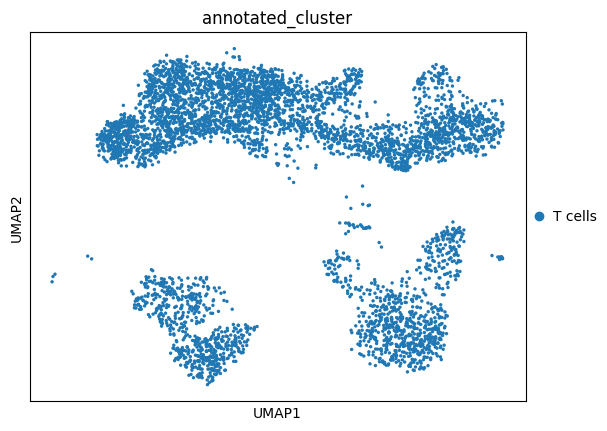

In [15]:
# Berechne den mittleren ORA-Score pro bestehendem Cluster (z.B. 'louvain' oder 'leiden')
#df = dc.get_acts(adata, obsm_key='ora_estimate').to_df()
df = adata.obsm['score_ora']
df['cluster'] = adata.obs['leiden_labels'] # oder 'leiden'
mean_df = df.groupby('cluster').mean()

# Für jeden Cluster den Zelltyp mit dem höchsten mittleren Score finden
cluster_to_celltype = mean_df.idxmax(axis=1).to_dict()

# Map die Annotationen zurück auf die Zellen
adata.obs['annotated_cluster'] = adata.obs['leiden_labels'].map(cluster_to_celltype)

# Finaler Plot
sc.pl.umap(adata, color='annotated_cluster')

In [16]:
classes = set(adata.obs['annotated_cluster'])
print(classes)

{'T cells'}


In [17]:
classes = set(adata.obs['anno'])
print(classes)

{'Memory B cells', 'HSCs', 'CD4+ naive T cells', 'cDCs', 'Plasma cells', 'Tregs', 'Cytotoxic T cells', 'CD14+ monocytes', 'CD8+ naive T cells', 'pDCs', 'Megakaryocytes', 'T helper cells', 'CD16+ monocytes', 'NK cells', 'Naive B cells'}


In [26]:
leiden_labels = set(adata.obs['leiden_labels'])
print(leiden_labels)

{'4', '9', '18', '7', '2', '12', '8', '16', '15', '14', '6', '10', '11', '5', '19', '17', '20', '3', '13', '1'}


In [25]:
print(marker_df)

                          source   target
                                         
0                    Hepatocytes     A1CF
1                     Germ cells   A2APA5
2                  Bergmann glia      A2M
3                     Mast cells   A3FIN4
4                     Mast cells   A4GALT
...                          ...      ...
8206  Adipocyte progenitor cells   ZNF521
8207                  Germ cells    ZNRF4
8208                  Germ cells    ZPBP2
8209                     Neurons  ZRSR2P1
8210        Embryonic stem cells  ZSCAN10

[8190 rows x 2 columns]


## 2. Versuch - nur mit Docs arbeiten

In [19]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import anndata as ad

# 1. Load Single Cell Data
adata = ad.io.read_h5ad('../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design.h5ad')

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Limit adata for tests to 5.000
adata = adata[:5000]

print(adata)

View of AnnData object with n_obs × n_vars = 5000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [20]:
markers = dc.op.resource("PanglaoDB", organism="human")

# Filter by canonical_marker and human
markers = markers[
    markers["human"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["human_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
print(markers)

                                source   target
                                               
18    Pulmonary alveolar type II cells    ABCA3
90                         Enterocytes    ACSL5
105                Smooth muscle cells    ACTA2
113                Smooth muscle cells    ACTG2
114                Myoepithelial cells    ACTG2
...                                ...      ...
8092                 Endothelial cells      VWF
8101          Luminal epithelial cells    WFDC2
8102                      Ductal cells    WFDC2
8129                         Podocytes      WT1
8197                   Ependymal cells  ZMYND10

[690 rows x 2 columns]


### Scoring

In [21]:
dc.mt.ulm(data=adata, net=markers, tmin=3)
print(adata.obsm["score_ulm"])

                        Acinar cells  Adipocytes  Alpha cells  Astrocytes  \
barcodekey                                                                  
BL1_1-AAACCTGAGAGGGATA     -0.911760    0.354551     1.204220   -0.668933   
BL1_1-AAACCTGAGCACCGCT     -0.640001    1.126013    -0.396823   -0.469553   
BL1_1-AAACCTGCACGAAACG     -0.794335   -0.730640     1.703757   -0.582783   
BL1_1-AAACCTGCAGGGTACA      0.531569   -0.748543    -0.504581   -0.597062   
BL1_1-AAACCTGGTTAAAGAC      0.314571    1.703159     1.495274   -0.663460   
...                              ...         ...          ...         ...   
BL1_2-AAACCTGCATCGATTG     -0.617564   -0.568044    -0.382911   -0.453092   
BL1_2-AAACCTGGTGACCAAG     -0.880383    0.425483     1.550904   -0.645912   
BL1_2-AAACCTGGTTCATGGT     -0.967686    0.458082     2.743414   -0.709963   
BL1_2-AAACCTGTCAGCTGGC      0.528725    0.915950     1.782253   -0.564205   
BL1_2-AAACCTGTCTTATCTG      2.226113    0.999401     2.151952    1.410717   

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_ulm']` of view, initializing view as actual.
  data.obsm[f"score_{name}"] = es


In [22]:
score = dc.pp.get_obsm(adata, key="score_ulm")
print(score)

AnnData object with n_obs × n_vars = 5000 × 47
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'score_ulm', 'padj_ulm'


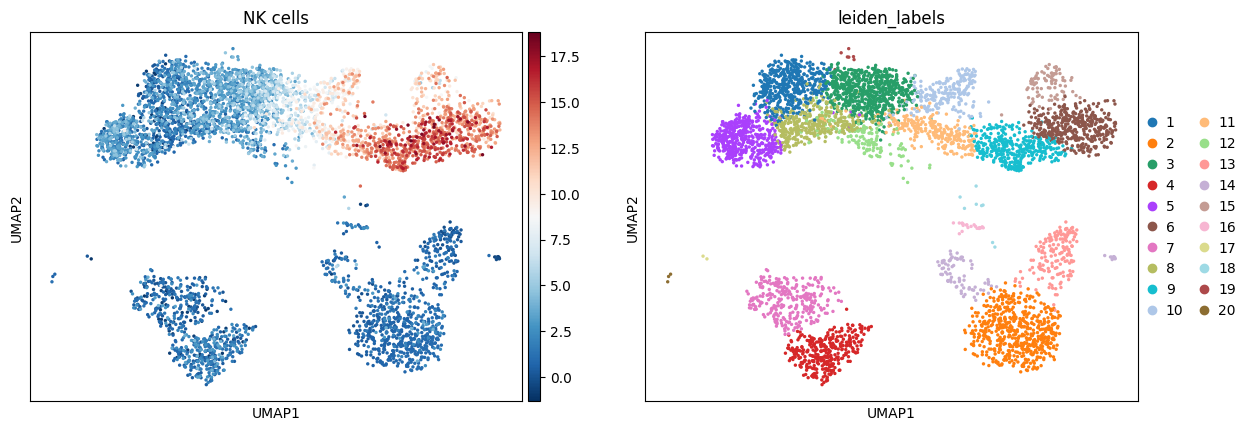

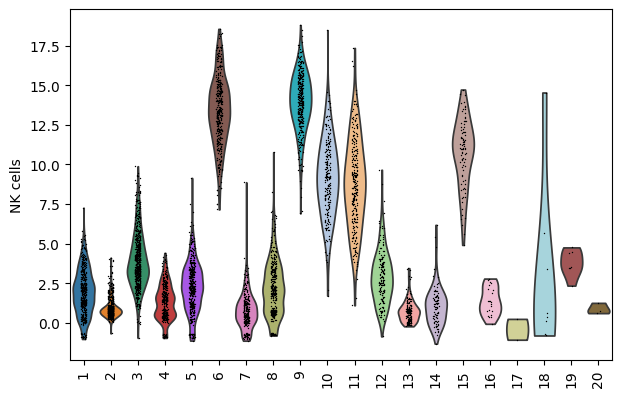

In [24]:
sc.pl.umap(score, color=["NK cells", "leiden_labels"], cmap="RdBu_r")
sc.pl.violin(score, keys=["NK cells"], groupby="leiden_labels", rotation=90)

In [26]:
df = dc.tl.rankby_group(adata=score, groupby="leiden_labels", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
print(df)

    group reference                      name       stat  meanchange  \
0      10      rest                  NK cells  12.529101    4.671099   
1      10      rest                   T cells  11.663238    4.116609   
2      10      rest       Gamma delta T cells   8.148884    3.607983   
3      10      rest  Luminal epithelial cells   5.949021    0.719598   
6      10      rest                 Platelets   5.255986    0.727129   
..    ...       ...                       ...        ...         ...   
929    17      rest                 Monocytes   0.437018    0.911723   
930    17      rest       Myoepithelial cells   0.448940    0.324475   
932    17      rest           Mesangial cells   0.262636    0.231868   
937    17      rest             Keratinocytes   0.086256    0.146276   
938    17      rest             B cells naive   0.060040    0.194454   

             pval          padj  
0    1.728002e-29  8.121611e-28  
1    6.719586e-26  1.579103e-24  
2    1.087307e-14  1.703447e-13  

In [27]:
n_ctypes = 3
ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
print(ctypes_dict)

{'1': ['T cells', 'Erythroid-like and erythroid precursor cells', 'Neurons'], '10': ['NK cells', 'T cells', 'Gamma delta T cells'], '11': ['NK cells', 'T cells', 'Platelets'], '12': ['T cells', 'Basal cells', 'Ductal cells'], '13': ['Macrophages', 'Hepatocytes', 'Dendritic cells'], '14': ['Dendritic cells', 'Macrophages', 'Neutrophils'], '15': ['Gamma delta T cells', 'NK cells', 'Beta cells'], '16': ['Plasmacytoid dendritic cells', 'Plasma cells', 'Hepatic stellate cells'], '17': ['Plasma cells', 'Plasmacytoid dendritic cells', 'Oligodendrocyte progenitor cells'], '18': ['Platelets', 'Endothelial cells', 'Smooth muscle cells'], '19': ['Monocytes', 'T cells', 'Neurons'], '2': ['Neutrophils', 'Macrophages', 'Dendritic cells'], '20': ['Alpha cells', 'Endothelial cells', 'Neurons'], '3': ['T cells', 'Luminal epithelial cells', 'Pericytes'], '4': ['B cells naive', 'B cells', 'Plasma cells'], '5': ['T cells', 'Astrocytes', 'Erythroid-like and erythroid precursor cells'], '6': ['Gamma delta T

/tmp/ipykernel_14083/3726861848.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


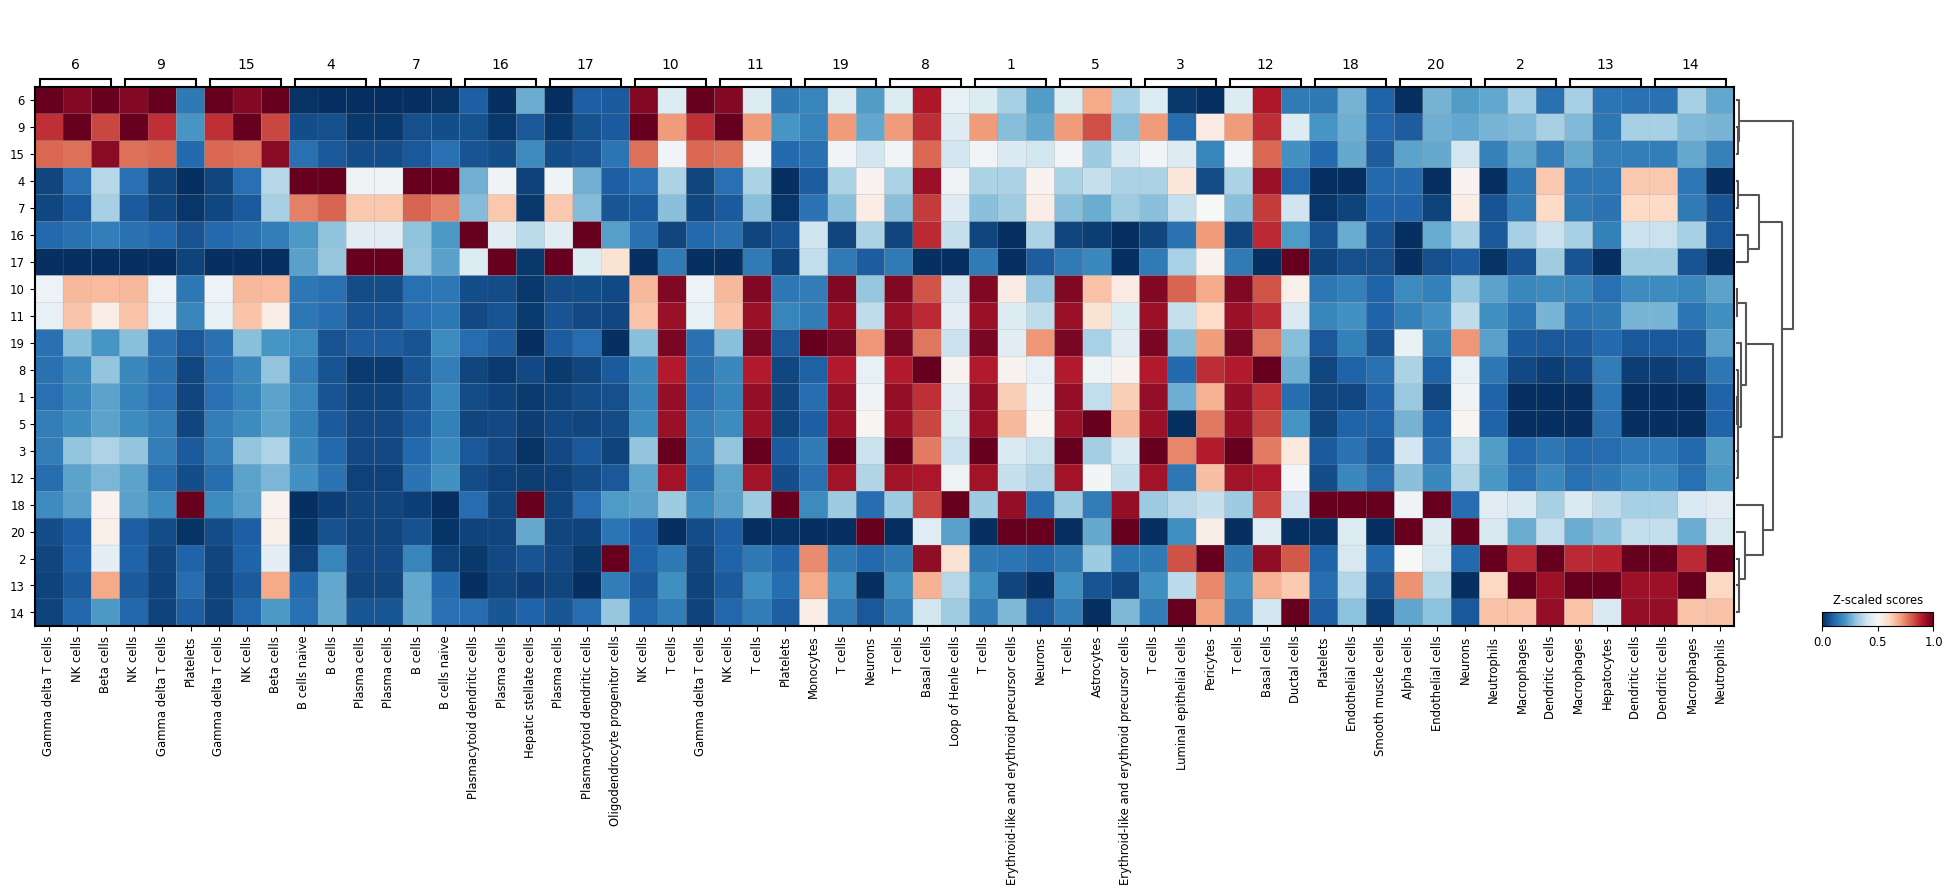

In [28]:
sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby="leiden_labels",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

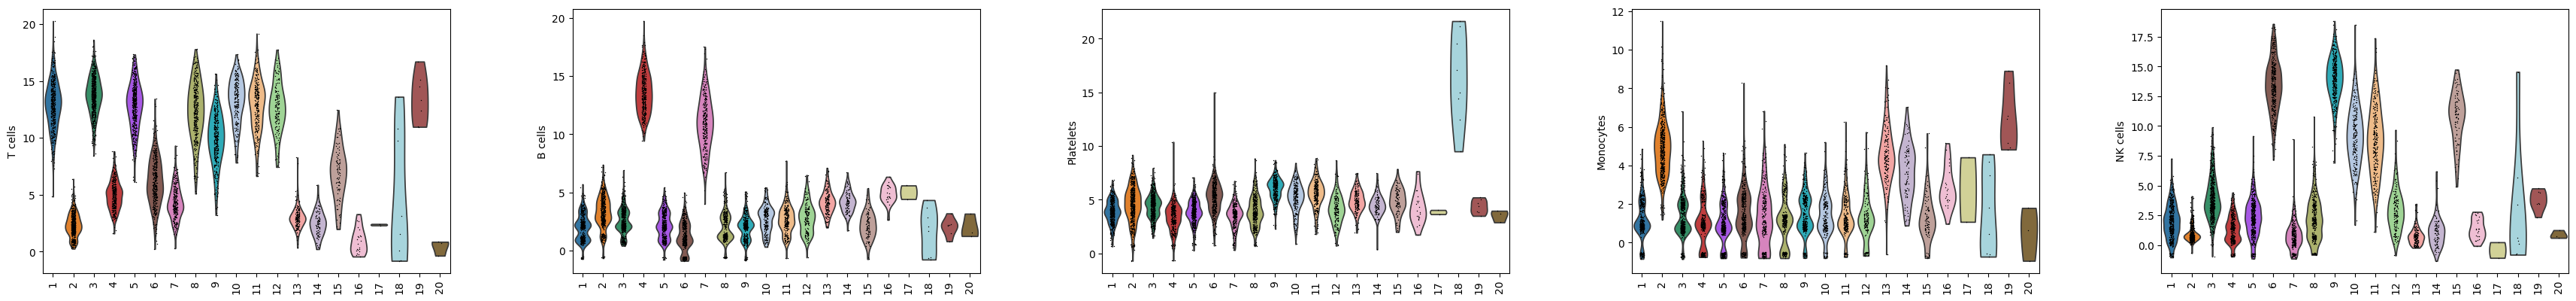

In [30]:
sc.pl.violin(
    adata=score,
    keys=["T cells", "B cells", "Platelets", "Monocytes", "NK cells"],
    groupby="leiden_labels",
    rotation=90,
)

In [31]:
dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
print(dict_ann)

{'10': 'NK cells', '6': 'Gamma delta T cells', '11': 'NK cells', '2': 'Neutrophils', '3': 'T cells', '1': 'T cells', '7': 'Plasma cells', '5': 'T cells', '9': 'NK cells', '13': 'Macrophages', '12': 'T cells', '4': 'B cells naive', '8': 'T cells', '15': 'Gamma delta T cells', '16': 'Plasmacytoid dendritic cells', '14': 'Dendritic cells', '18': 'Platelets', '19': 'Monocytes', '20': 'Alpha cells', '17': 'Plasma cells'}


/tmp/ipykernel_14083/2508462774.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


In [32]:
# Update cats
adata.obs["leiden_labels"] = adata.obs["leiden_labels"].cat.rename_categories(dict_ann)

ValueError: Categorical categories must be unique

In [36]:
# WICHTIG: Zuerst zu category konvertieren, falls noch nicht geschehen
import pandas as pd

if not isinstance(adata.obs["leiden_labels"].dtype, pd.CategoricalDtype):
    print("Konvertiere leiden_labels zu category...")
    adata.obs["leiden_labels"] = adata.obs["leiden_labels"].astype('category')

# Jetzt können wir rename_categories nutzen
dict_ann_complete = {cat: dict_ann.get(cat, cat) for cat in adata.obs["leiden_labels"].cat.categories}

print("Mapping:")
print(dict_ann_complete)

adata.obs["leiden_labels"] = adata.obs["leiden_labels"].cat.rename_categories(dict_ann_complete)

print("Neue Label:")
print(adata.obs["leiden_labels"].unique())

Konvertiere leiden_labels zu category...
Mapping:
{'Alpha cells': 'Alpha cells', 'B cells naive': 'B cells naive', 'Dendritic cells': 'Dendritic cells', 'Gamma delta T cells': 'Gamma delta T cells', 'Macrophages': 'Macrophages', 'Monocytes': 'Monocytes', 'NK cells': 'NK cells', 'Neutrophils': 'Neutrophils', 'Plasma cells': 'Plasma cells', 'Plasmacytoid dendritic cells': 'Plasmacytoid dendritic cells', 'Platelets': 'Platelets', 'T cells': 'T cells'}
Neue Label:
['NK cells', 'Gamma delta T cells', 'Neutrophils', 'T cells', 'Plasma cells', ..., 'Plasmacytoid dendritic cells', 'Dendritic cells', 'Platelets', 'Monocytes', 'Alpha cells']
Length: 12
Categories (12, object): ['Alpha cells', 'B cells naive', 'Dendritic cells', 'Gamma delta T cells', ..., 'Plasma cells', 'Plasmacytoid dendritic cells', 'Platelets', 'T cells']


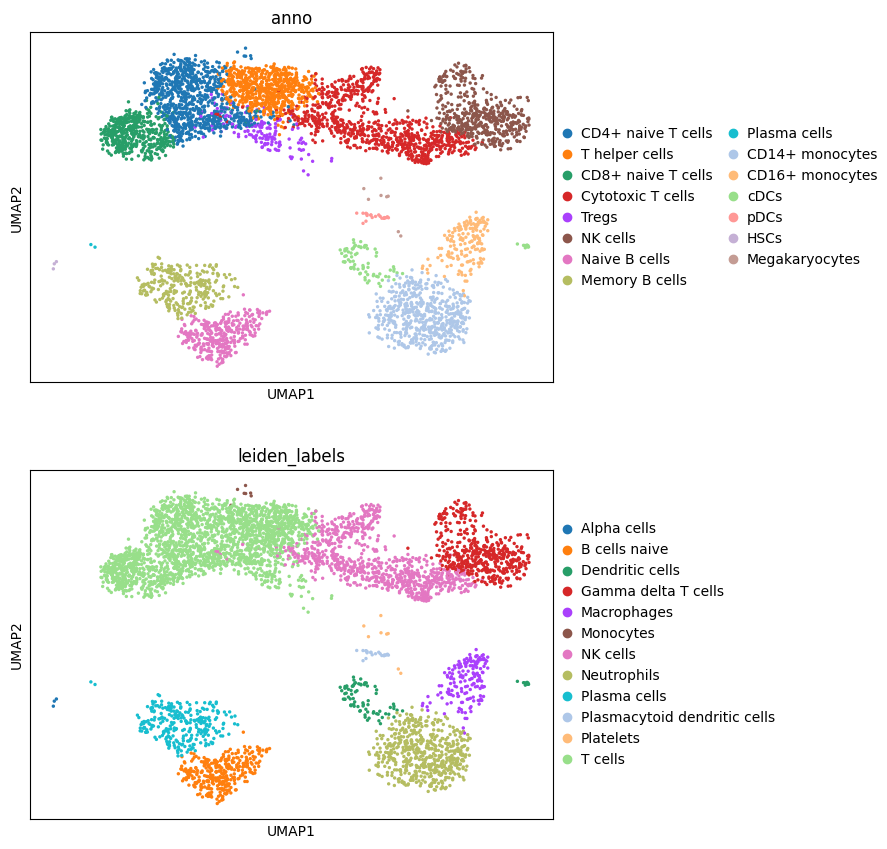

In [38]:
sc.pl.umap(
    adata=adata,
    color=["anno", "leiden_labels"],
    ncols=1,
)

In [41]:
print(type(adata.obs['anno']))

<class 'pandas.core.series.Series'>
